<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-burst-prediction/blob/main/MSc_project_data_pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import packages required

from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#import attributes

attributes = pd.read_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding='latin1')

In [ ]:
# removing Asset ID and dates - not needed for further analysis

attributes = attributes.iloc[:, 3:12]

# Feature engineering

(array([3623.,  983.,  721.,  664.,  505.,  432.,  366.,  283.,  248.,
         231.,  208.,  183.,  161.,  141.,  115.,   92.,   72.,   71.,
          44.,   18.]),
 array([2.00000e+00, 3.80550e+02, 7.59100e+02, 1.13765e+03, 1.51620e+03,
        1.89475e+03, 2.27330e+03, 2.65185e+03, 3.03040e+03, 3.40895e+03,
        3.78750e+03, 4.16605e+03, 4.54460e+03, 4.92315e+03, 5.30170e+03,
        5.68025e+03, 6.05880e+03, 6.43735e+03, 6.81590e+03, 7.19445e+03,
        7.57300e+03]),
 <BarContainer object of 20 artists>)

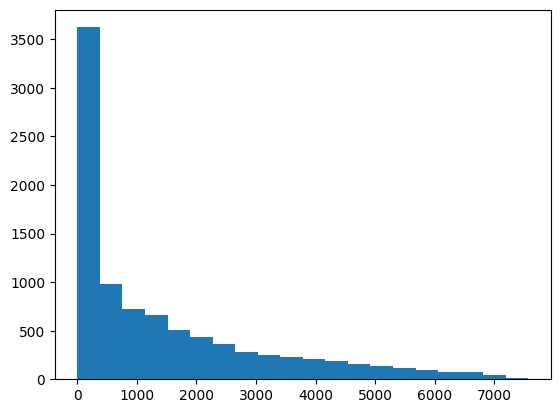

In [ ]:
# examine time-to-break

plt.hist(attributes['Time-to-break'], bins = 20)

# comment: highly skewed

<Axes: ylabel='Time-to-break'>

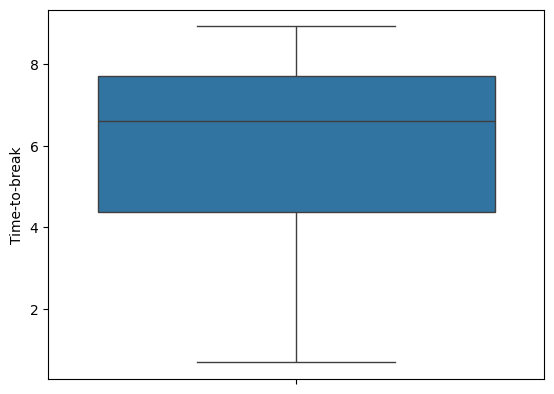

In [ ]:
sns.boxplot(np.log(attributes['Time-to-break']))

### Numerical attributes

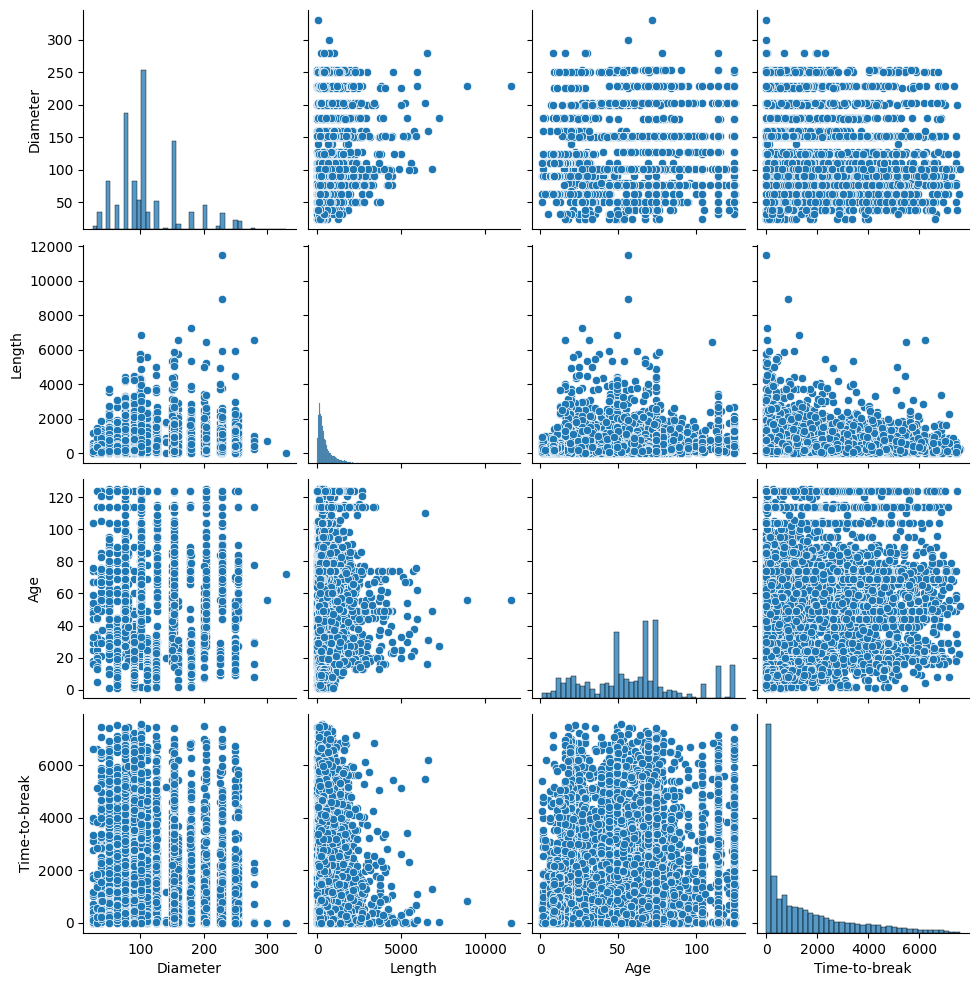

In [ ]:
# examine correlations between numerical attributes

sns.pairplot(attributes)

Text(0, 0.5, 'Time-to-break (days)')

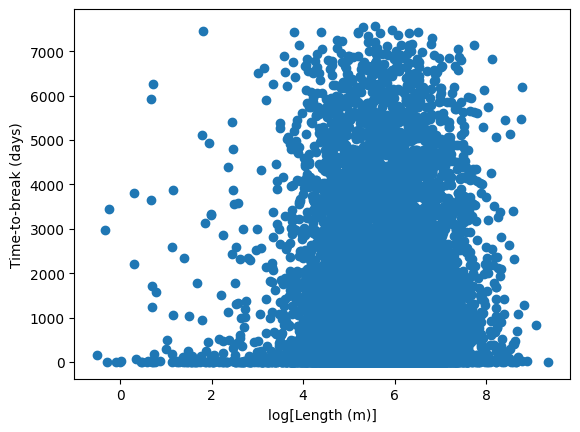

In [ ]:
# length vs time-to-break

plt.scatter(np.log(attributes['Length']), attributes["Time-to-break"]) # take log of length as highly skewed
plt.xlabel("log[Length (m)]")
plt.ylabel("Time-to-break (days)")


# length doesn't refelct true length, because asset ID corresponds to how it was drawn

# comment: no strong relationship

In [ ]:
# length vs time-to-break

test = stats.spearmanr(a = attributes['Length'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)



# comment: weak positive relationship

statistic 0.037280441246422234
p-value 0.0003583727365512998


Text(0, 0.5, 'Time-to-break (days)')

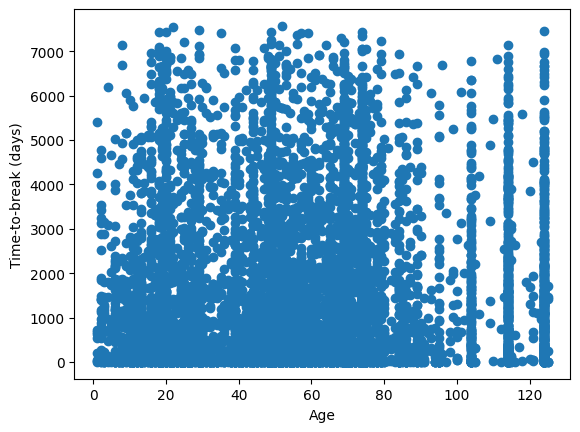

In [ ]:
# time to break vs age

plt.scatter(attributes['Age'], attributes["Time-to-break"])
plt.xlabel("Age")
plt.ylabel("Time-to-break (days)")

# note: test for relationship betwene material type and age
# note: only have 20 years of burst data

# comment: no relationship

In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Age'], b = attributes["Time-to-break"])



print("statistic", test.statistic)
print("p-value", test.pvalue)



# comment: weak positive relationship

statistic 0.04195514543770295
p-value 5.897418516055191e-05


Text(0, 0.5, 'Time-to-break (days)')

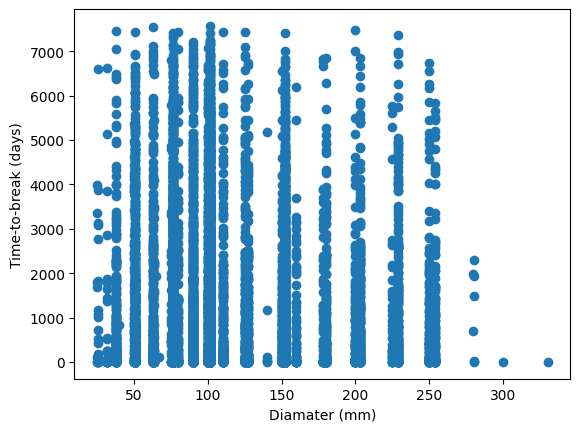

In [ ]:
# diamater vs time to break

plt.scatter(attributes['Diameter'], attributes["Time-to-break"])
plt.xlabel("Diamater (mm)")
plt.ylabel("Time-to-break (days)")

# note: test based on material

# comment: no obvious relationship

In [ ]:
# diamater vs time-to-break

test = stats.spearmanr(a = attributes['Diameter'], b = attributes["Time-to-break"])
test2 = stats.spearmanr(a = attributes_filtered['Diameter'], b = attributes_filtered["Time-to-break"])



print("statistic", test.statistic)
print("p-value", test.pvalue)

print("statistic_2", test2.statistic)
print("p-value_2", test2.pvalue)

# comment: weak negative relationship

statistic -0.022833327687763666
p-value 0.027089129774149272
statistic_2 0.006916223022529912
p-value_2 0.562136217073457


Text(0, 0.5, 'Time-to-break (days)')

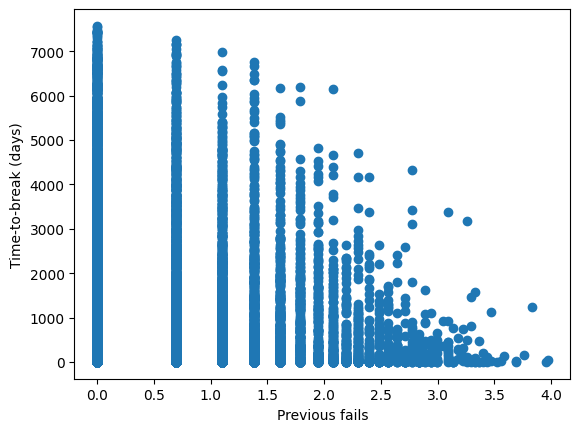

In [ ]:
# previous fails vs time-to-break


plt.scatter(np.log(attributes['previous fails']), attributes["Time-to-break"]) # take logs of previous fails as highly skewed
plt.xlabel("Previous fails")
plt.ylabel("Time-to-break (days)")

# note: only have 20 years of burst data (don't know what happened with assets previously) - for example, no difference in burst rate betwene 70 and 80 years

# comment: some negative relationship

In [ ]:
# previous vs time-to-break

test = stats.spearmanr(a = attributes['previous fails'], b = attributes["Time-to-break"])
test2 = stats.spearmanr(a = attributes_filtered['previous fails'], b = attributes_filtered["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)

print("statistic", test2.statistic)
print("p-value", test2.pvalue)

# weak negative relationship

statistic -0.1901734009842991
p-value 5.039591996993108e-77
statistic -0.2804461111868036
p-value 3.728588071508317e-127


### Nominal attributes

Text(0, 0.5, 'log[Time-to-break]')

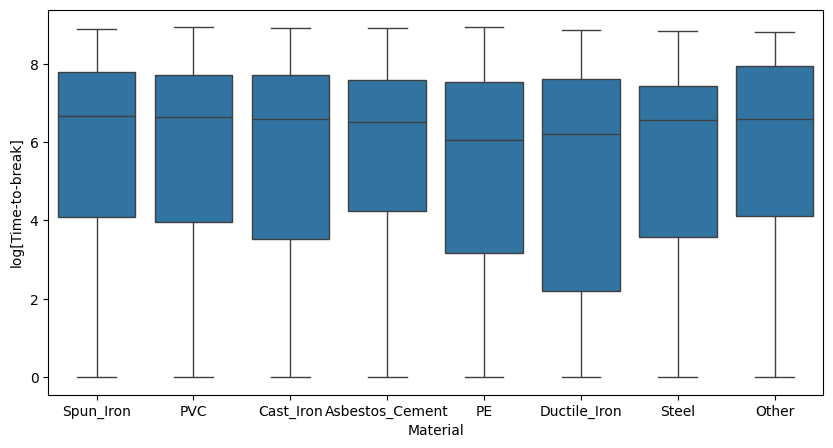

In [ ]:
# material vs time-to-break

plt.figure(figsize = (10, 5))
sns.boxplot( y = np.log(attributes["Time-to-break"]), x = attributes["Material"]) # adding a constant 10 to avoid infinity at time-to-break = 0
plt.ylabel("log[Time-to-break]")

# comment: some materials such as PE or Steel seem to have slightly lower time-to-break

In [ ]:
# splitting up material into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Material"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Material")


asbestos_cement = np.array(material_pivot["Asbestos_Cement"][pd.notnull(material_pivot["Asbestos_Cement"])])

spun_iron = np.array(material_pivot["Spun_Iron"][pd.notnull(material_pivot["Spun_Iron"])])

PVC = np.array(material_pivot["PVC"][pd.notnull(material_pivot["PVC"])])

cast_iron = np.array(material_pivot["Cast_Iron"][pd.notnull(material_pivot["Cast_Iron"])])

PE = np.array(material_pivot["PE"][pd.notnull(material_pivot["PE"])])

ductile_iron = np.array(material_pivot["Ductile_Iron"][pd.notnull(material_pivot["Ductile_Iron"])])

steel = np.array(material_pivot["Steel"][pd.notnull(material_pivot["Steel"])])

other = np.array(material_pivot["Other"][pd.notnull(material_pivot["Other"])])



In [ ]:
# splitting up material into categories for one-way ANOVA - filtered data

material_subset_2 = attributes_filtered[["Time-to-break", "Material"]]

material_pivot = material_subset_2.pivot(values = "Time-to-break", columns = "Material")


asbestos_cement_2 = np.array(material_pivot["Asbestos_Cement"][pd.notnull(material_pivot["Asbestos_Cement"])])

spun_iron_2 = np.array(material_pivot["Spun_Iron"][pd.notnull(material_pivot["Spun_Iron"])])

PVC_2 = np.array(material_pivot["PVC"][pd.notnull(material_pivot["PVC"])])

cast_iron_2 = np.array(material_pivot["Cast_Iron"][pd.notnull(material_pivot["Cast_Iron"])])

PE_2 = np.array(material_pivot["PE"][pd.notnull(material_pivot["PE"])])

ductile_iron_2 = np.array(material_pivot["Ductile_Iron"][pd.notnull(material_pivot["Ductile_Iron"])])

steel_2 = np.array(material_pivot["Steel"][pd.notnull(material_pivot["Steel"])])

other_2 = np.array(material_pivot["Other"][pd.notnull(material_pivot["Other"])])



In [ ]:
# one-way ANOVA for material

test = stats.f_oneway(np.log(asbestos_cement),
               np.log(spun_iron),
               np.log(PVC),
               np.log(cast_iron),
               np.log(PE),
               np.log(ductile_iron),
               np.log(steel),
               np.log(other))

test2 = stats.f_oneway(np.log(asbestos_cement_2),
               np.log(spun_iron_2),
               np.log(PVC_2),
               np.log(cast_iron_2),
               np.log(PE_2),
               np.log(ductile_iron_2),
               np.log(steel_2),
               np.log(other_2))


print("statistic", np.exp(test.statistic))
print("p-value",  test.pvalue)

print("statistic", np.exp(test2.statistic))
print("p-value", test2.pvalue)


# comment: significant different in time-to-break between different materials

statistic 127.7030208008743
p-value 1.8017001975737723e-05
statistic 700.0828188634605
p-value 9.88565565027769e-08


Text(0, 0.5, 'log[Time-to-break]')

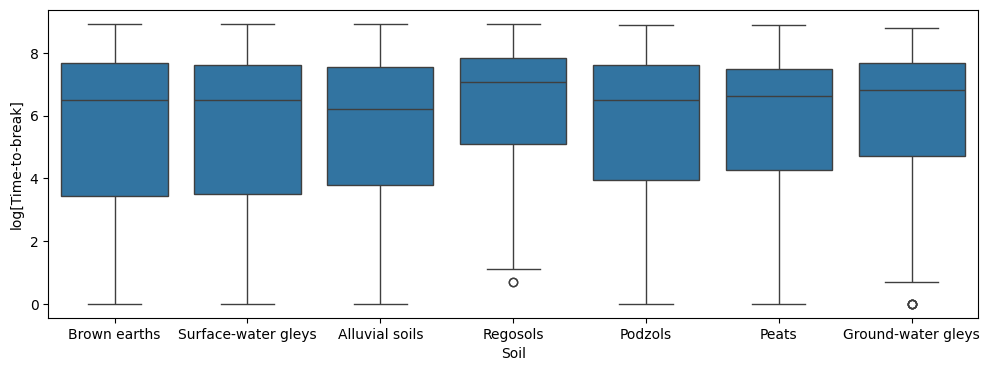

In [ ]:
# soil vs time-to-break

plt.figure(figsize=(12,4))
sns.boxplot( y = np.log(attributes["Time-to-break"]), x = attributes["Soil"])
plt.ylabel("log[Time-to-break]")

# comment: some soil types appear to have longer time to break such as Regosols, and some have slightly shorter such as Peats

In [ ]:
# splitting up soils into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Soil"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Soil")


brown_earths = np.array(material_pivot["Brown earths"][pd.notnull(material_pivot["Brown earths"])])

surface_water_gleys = np.array(material_pivot["Surface-water gleys"][pd.notnull(material_pivot["Surface-water gleys"])])

alluvial = np.array(material_pivot["Alluvial soils"][pd.notnull(material_pivot["Alluvial soils"])])

regosols = np.array(material_pivot["Regosols"][pd.notnull(material_pivot["Regosols"])])

podzols = np.array(material_pivot["Podzols"][pd.notnull(material_pivot["Podzols"])])

peats = np.array(material_pivot["Peats"][pd.notnull(material_pivot["Peats"])])

ground_water_gleys = np.array(material_pivot["Ground-water gleys"][pd.notnull(material_pivot["Ground-water gleys"])])



In [ ]:
# one-way anova for soil

test = stats.f_oneway(np.log(brown_earths),
               np.log(surface_water_gleys),
               np.log(alluvial),
               np.log(regosols),
               np.log(podzols),
               np.log(peats),
               np.log(ground_water_gleys))

print(np.exp(test.statistic))
print(test.pvalue)

#comment: no significnat different between time-to-break by soil type

3.776338541826947
0.24024750658295302


Text(0, 0.5, 'log[Time-to-break]')

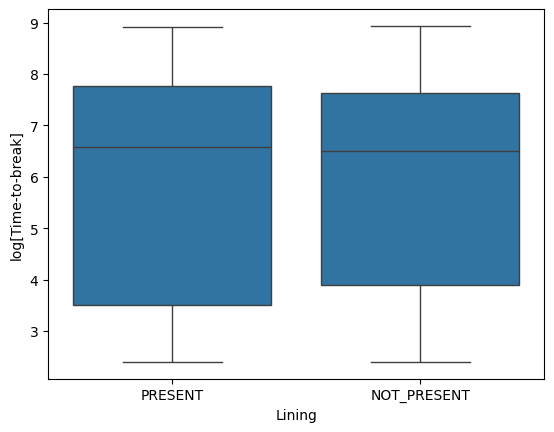

In [ ]:
# lining vs time-to- break

sns.boxplot( y = np.log(attributes["Time-to-break"] + 10), x = attributes["Lining"])
plt.ylabel("log[Time-to-break]")

# comment: assets with lining present appear to have longer time to break

In [ ]:
# splitting up lining into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Lining"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Lining")


present = np.array(material_pivot["PRESENT"][pd.notnull(material_pivot["PRESENT"])])

not_present = np.array(material_pivot["NOT_PRESENT"][pd.notnull(material_pivot["NOT_PRESENT"])])


In [ ]:
# one-way anova for lining

test = stats.f_oneway(np.log(present),
               np.log(not_present))

print(np.exp(test.statistic))
print(test.pvalue)

#comment: no significnat different between time-to-break by lining

1.5932982645224296
0.49493971920259927


Text(0, 0.5, 'log[time-to-break]')

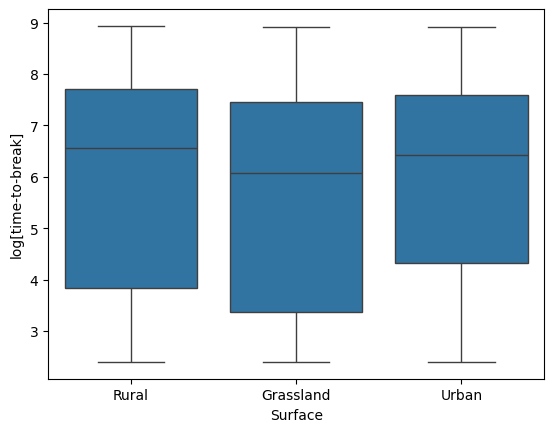

In [ ]:
# time-to-break vs surface
sns.boxplot( y = np.log(attributes["Time-to-break"] + 10), x = attributes["Surface"])
plt.ylabel("log[time-to-break]")

In [ ]:
# splitting up Surface into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Surface"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Surface")


rural = np.array(material_pivot["Rural"][pd.notnull(material_pivot["Rural"])])

grassland = np.array(material_pivot["Grassland"][pd.notnull(material_pivot["Grassland"])])

urban = np.array(material_pivot["Urban"][pd.notnull(material_pivot["Urban"])])

In [ ]:
# one-way anova for surface

test = stats.f_oneway(np.log(rural),
               np.log(grassland),
                      np.log(urban))

print(np.exp(test.statistic))
print(test.pvalue)

# test for interation between surface and material - for example in urban could have more cast iron
#comment: significant difference between surface type detected

1629.967086231374
0.0006170990525419815
